<a href="https://colab.research.google.com/github/pedrorfdev/deteccao_fraudes/blob/main/deteccao-anomalias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


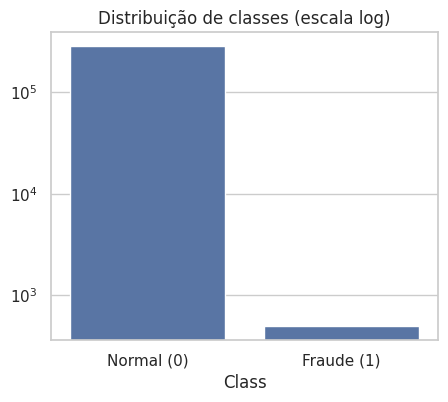

Treino: (227845, 31) | fraude: 0.001729245759178389
Teste : (56962, 31) | fraude: 0.0017204452090867595


In [ ]:
# %% [markdown]
# # Detecção de Fraude em Cartão de Crédito
# Pipeline: EDA, preparação, Regressão Logística + Random Forest, avaliação por
# recall/precisão/F1 (desbalanceamento severo), ajuste de limiar e importância de variáveis.
# Dataset: https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv

# %% [markdown]
# ## 1. Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score, f1_score
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

# %% [markdown]
# ## 2. Explore
DATA_URL = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(DATA_URL)
print(df.shape)
df.head()

# %%
df.isna().sum().sum()

# %%
class_counts = df["Class"].value_counts()
print(class_counts)
print((df["Class"].value_counts(normalize=True) * 100).round(4))

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax)
ax.set_xticks(range(len(class_counts)))
ax.set_xticklabels(["Normal (0)", "Fraude (1)"])
ax.set_yscale("log")
ax.set_title("Distribuição de classes (escala log)")
plt.show()

# %% [markdown]
# A fraude é raríssima (~0,17%), então acurácia não serve de métrica aqui.

# %% [markdown]
# ## 3. Prepare
df["LogAmount"] = np.log1p(df["Amount"])

feature_cols = [c for c in df.columns if c != "Class"]
X = df[feature_cols].copy()
y = df["Class"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Treino:", X_train.shape, "| fraude:", y_train.mean())
print("Teste :", X_test.shape,  "| fraude:", y_test.mean())

# %%
scale_cols = ["Time", "Amount", "LogAmount"]
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

# %% [markdown]
# ## 4. Treine
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

# %%
rf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE
)
rf.fit(X_train_scaled, y_train)
proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

# %%
results = {
    "Logistic Regression": proba_lr,
    "Random Forest": proba_rf,
}

# %% [markdown]
# ## 5. Avalie
def evaluate(name, y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    print(f"=== {name} (limiar={threshold}) ===")
    print(classification_report(y_true, pred, target_names=["Normal", "Fraude"], digits=4))
    print("ROC AUC:", round(roc_auc_score(y_true, proba), 4))
    print("PR AUC (Average Precision):", round(average_precision_score(y_true, proba), 4))
    print()
    return pred

preds_default = {name: evaluate(name, y_test, proba) for name, proba in results.items()}

# %%
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name, proba in results.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.4f})")

    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, proba):.4f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_title("Curva ROC")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].legend()

axes[1].set_title("Curva Precisão-Recall")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precisão")
axes[1].legend()

plt.tight_layout()
plt.show()

# %%
for name, pred in preds_default.items():
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Normal", "Fraude"]).plot(cmap="Blues", values_format="d")
    plt.title(f"Matriz de confusão — {name}")
    plt.show()

# %% [markdown]
# ### Ajuste do limiar
def best_threshold(y_true, proba):
    thresholds = np.linspace(0.01, 0.99, 99)
    scores = [f1_score(y_true, (proba >= t).astype(int), zero_division=0) for t in thresholds]
    best_idx = int(np.argmax(scores))
    return thresholds[best_idx], scores[best_idx]

best_thresholds = {}
for name, proba in results.items():
    t, f1 = best_threshold(y_test, proba)
    best_thresholds[name] = t
    print(f"{name}: limiar={t:.2f} | F1 fraude={f1:.4f}")

# %%
for name, proba in results.items():
    evaluate(name, y_test, proba, threshold=best_thresholds[name])

# %% [markdown]
# **Preencher depois de rodar:** qual modelo e limiar você escolheu como final, e por quê.

# %% [markdown]
# ## 6. Explique
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
importances.head(15).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 15 variáveis mais importantes — Random Forest")
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 7. Conclusão
# Preencher depois de rodar:
# - Qual modelo teve melhor recall/F1 na fraude?
# - Limiar final escolhido e por quê?
# - O que a importância de variáveis mostrou sobre o que mais pesa pra marcar fraude?
# - O que você mudou em relação ao pipeline da Expert?